## Questão 1

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

ModuleNotFoundError: No module named 'scipy'

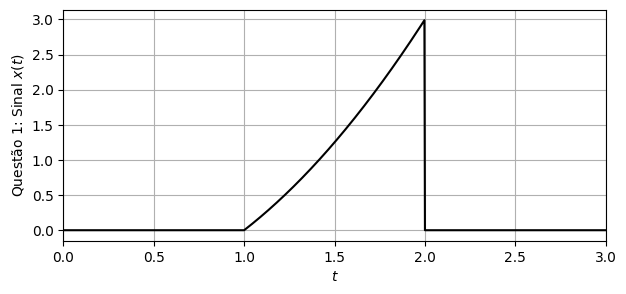

Energia (computacional) = 2.5173
Energia (analítica) = 2.5333


In [ ]:
t_inicio = 0
t_fim = 3
npoints = 1000
t = np.linspace(t_inicio, t_fim, npoints)
dt = (t_fim - t_inicio) / npoints

u1 = 1.0 * (t >= 1)
u2 = 1.0 * (t >= 2)
x = (t**2 - 1) * (u1 - u2)

plt.figure(figsize=(7,3))
plt.plot(t,x, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 1: Sinal $x(t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

Ex_num = np.sum(x**2) * dt
Ex_ana = 38 / 15

print(f'Energia (computacional) = {Ex_num:.4f}')
print(f'Energia (analítica) = {Ex_ana:.4f}')

## Questão 2

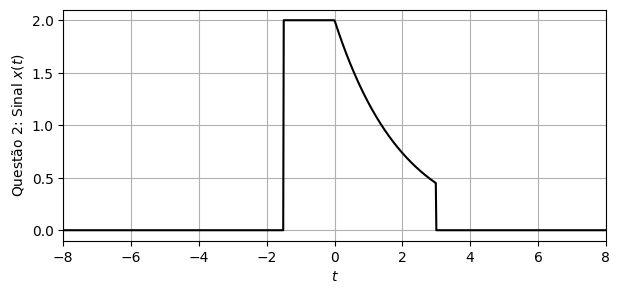

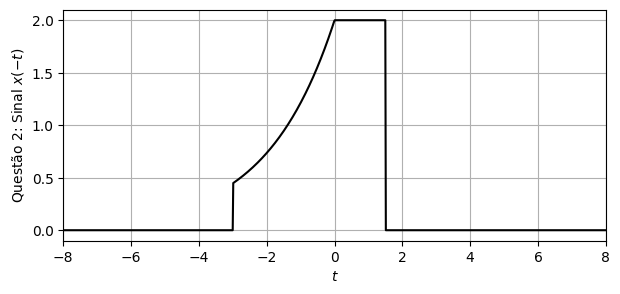

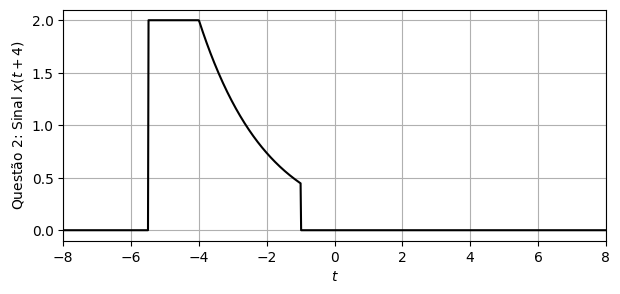

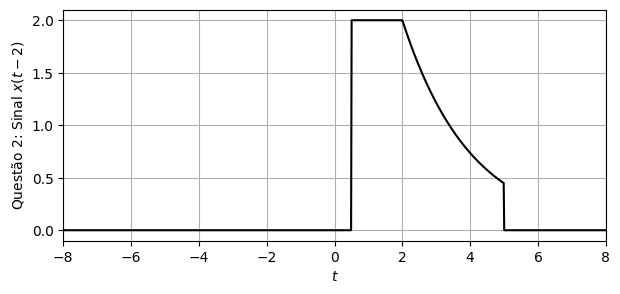

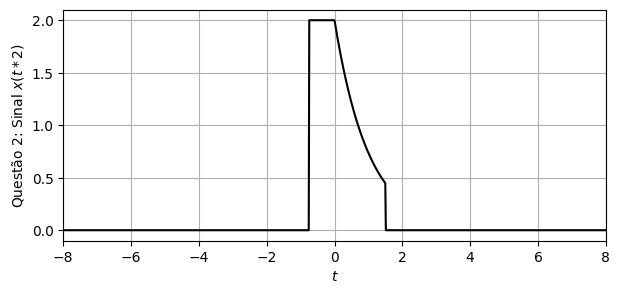

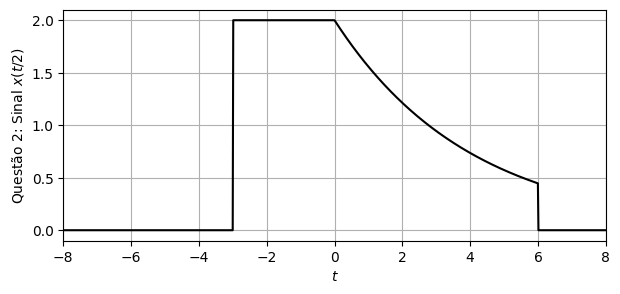

In [ ]:
def sinal(t):
    return 2*(np.logical_and(t >= -1.5, t < 0)) + (2*np.exp(-t/2))*(np.logical_and(t >= 0, t <= 3))

t_inicio =-8
t_fim = 8
npoints = 1000
t = np.linspace(t_inicio, t_fim, npoints)
x1 = sinal(t)
x2 = sinal(-t)
x3 = sinal(t+4)
x4 = sinal(t-2)
x5 = sinal(t*2)
x6 = sinal(t/2)

plt.figure(figsize=(7,3))
plt.plot(t,x1, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x2, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(-t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x3, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t + 4)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x4, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t - 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x5, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t * 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x6, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t / 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

## Questão 3

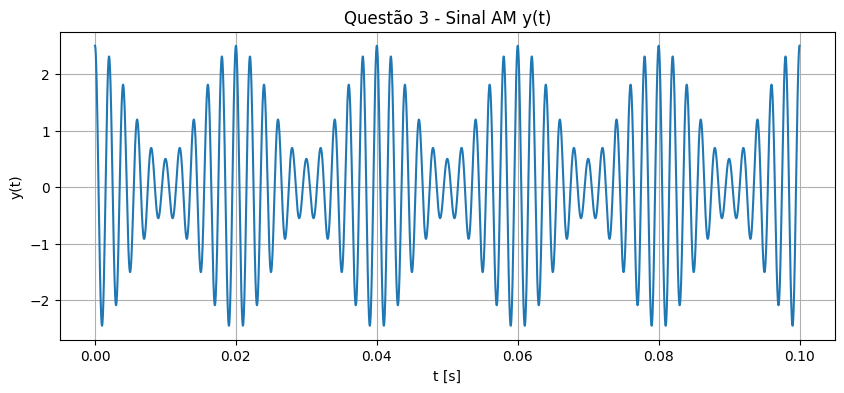

In [ ]:
fm = 50
fc = 500
A = 1.5

t = np.linspace(0, 0.1, 5000)

x = np.cos(2 * np.pi * fm * t)
y = (A + x) * np.cos(2 * np.pi * fc * t)

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.title("Questão 3 - Sinal AM y(t)")
plt.xlabel("t [s]")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

## Questão 4 (a)

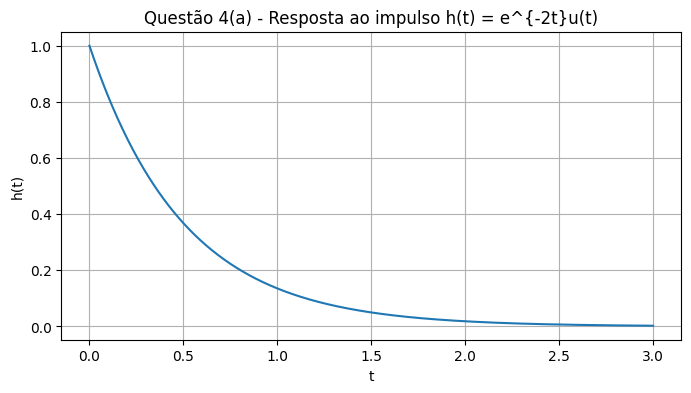

In [ ]:
t = np.linspace(0, 3, 1000)
h = np.exp(-2*t)

plt.figure(figsize=(8, 4))
plt.plot(t, h)
plt.title("Questão 4(a) - Resposta ao impulso h(t) = e^{-2t}u(t)")
plt.xlabel("t")
plt.ylabel("h(t)")
plt.grid(True)
plt.show()

## Questão 4 (b) 

A resposta ao impulso do sistema é dada por:

$$
h(t) = e^{-2t}u(t)
$$

O sistema é causal, pois sua resposta ao impulso é nula para valores de tempo negativos. Como existe o degrau unitário \(u(t)\), tem-se:

$$
h(t) = 0, \quad t < 0
$$

Logo, o sistema não responde antes da aplicação da entrada, caracterizando um sistema causal.

Para verificar a estabilidade, utiliza-se a condição de estabilidade BIBO para sistemas lineares e invariantes no tempo. Um sistema LIT é estável se:

$$
\int_{-\infty}^{\infty} |h(t)| \, dt < \infty
$$

Substituindo \(h(t)\):

$$
\int_{-\infty}^{\infty} |h(t)| \, dt
=
\int_0^{\infty} e^{-2t} \, dt
$$

Calculando a integral:

$$
\int_0^{\infty} e^{-2t} \, dt
=
\left[-\frac{1}{2}e^{-2t}\right]_0^{\infty}
$$

$$
=
0 - \left(-\frac{1}{2}\right)
=
\frac{1}{2}
$$

Como o resultado é finito, conclui-se que o sistema é **estável**.

Portanto, o sistema é **causal e estável**.

## Questão 4 (d)

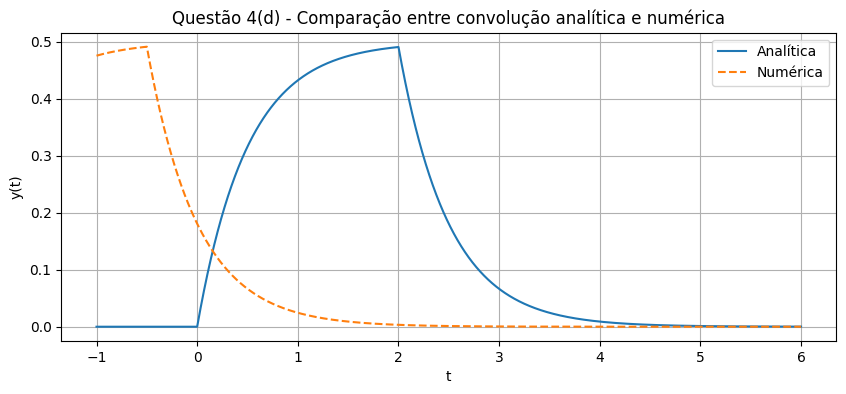

In [ ]:
dt = 0.001
t = np.arange(-1, 6, dt)

x = np.where((t >= 0) & (t < 2), 1, 0)
h = np.where(t >= 0, np.exp(-2*t), 0)

y_num = np.convolve(x, h, mode="same") * dt

def y_analitica(t):
    return np.where(
        t < 0,
        0,
        np.where(
            t < 2,
            (1 - np.exp(-2*t)) / 2,
            (np.exp(-2*(t-2)) - np.exp(-2*t)) / 2
        )
    )

y_an = y_analitica(t)

plt.figure(figsize=(10, 4))
plt.plot(t, y_an, label="Analítica")
plt.plot(t, y_num, "--", label="Numérica")
plt.title("Questão 4(d) - Comparação entre convolução analítica e numérica")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

## Questão 5 (a)

### (a) Um determinado circuito elétrico com tensão de entrada $v_i(t)$ e tensão de saída $v_o(t)$ é modelado através da seguinte equação diferencial ordinária:

$$\frac{d^2v_o(t)}{dt^2} + 7\frac{dv_o(t)}{dt} + 10v_o(t) = \frac{dv_i(t)}{dt} + 6v_i(t)$$

As condições iniciais são $v_o(0) = 6\text{V}$ e $v_o'(0) = -4\text{V/s}$, com entrada $x(t) = 6e^{-3t}u(t)$.

### Método Clássico (Analítico)
A solução é composta pela resposta natural $v_n(t)$ e forçada $v_f(t)$:
1. **Natural:** Raízes de $λ^2 + 7λ  + 10 = 0 \implies λ_1 = -2, λ_2 = -5$ (Raizes reais e distintas) 
2. **Forçada:** Para a entrada $v_i(t) = 6e^{-3t}$, o lado direito da EDO resulta em $18e^{-3t}$. Sabendo que $v_f(t) = Ke^{-3t}$, encontramos $K = -9$.
3. **Solução Geral:** $v_o(t) = C_1 e^{-2t} + C_2 e^{-5t} - 9e^{-3t}$.
4. **Condições Iniciais:** Aplicando $v_o(0)=6$ e $v_o'(0)=-4$, obtemos $C_1 = 44/3$ e $C_2 = 1/3$.

$$v_o(t) = y(t) = \left( \frac{44}{3}e^{-2t} + \frac{1}{3}e^{-5t} - 9e^{-3t} \right) u(t)$$

## Questão 5 (b)

### Plot do sinal de saída para $0 \leq t \leq 2$

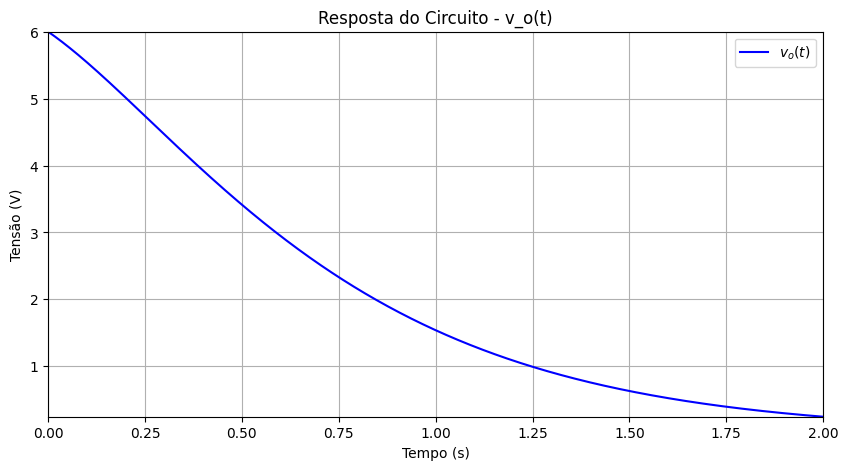

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t_plot = np.linspace(0, 2, 1000)

def v_o_analitica(t):
    return (44/3)*np.exp(-2*t) + (1/3)*np.exp(-5*t) - 9*np.exp(-3*t)

y_vals = v_o_analitica(t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, y_vals, label=r'$v_o(t)$', color='blue')
plt.xlim(0, 2)
plt.ylim(y_vals.min(), y_vals.max())
plt.title('Resposta do Circuito - v_o(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')
plt.grid(True)
plt.legend()
plt.show()

## Questão 5 (c)

### (c) Computação Simbólica e Comparação
Utilização da biblioteca `sympy` para resolver a EDO e validar os resultados obtidos manualmente.

In [ ]:
import sympy as sp
from IPython.display import display

t_sym = sp.symbols('t', real=True, positive=True)
vo = sp.Function('vo')
vi = 6 * sp.exp(-3*t_sym)

edo = sp.Eq(vo(t_sym).diff(t_sym, t_sym) + 7*vo(t_sym).diff(t_sym) + 10*vo(t_sym), 
            vi.diff(t_sym) + 6*vi)

ics = {vo(0): 6, vo(t_sym).diff(t_sym).subs(t_sym, 0): -4}

sol_simbolica = sp.dsolve(edo, ics=ics)

if isinstance(sol_simbolica, list):
    sol_final = sol_simbolica[0]
else:
    sol_final = sol_simbolica

print("Expressão obtida via SymPy:")
display(sol_final)

v_simb_func = sp.lambdify(t_sym, sol_final.rhs, 'numpy')
erro_max = np.abs(y_vals - v_simb_func(t_plot)).max()
print(f"Erro máximo de comparação: {erro_max:.2e}")

Expressão obtida via SymPy:


Eq(vo(t), (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t))

Erro máximo de comparação: 2.66e-15
